In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
imgFile = "moon.jpg"
img = cv2.imread(imgFile, 0)

# Check if image loaded correctly
if img is None:
    print("Error: Image not found.")
else:
    print("Image loaded successfully")

Image loaded successfully


In [4]:
manual_kernel = np.array([
    [0,  1,  0],
    [1, -4,  1],
    [0,  1,  0]
])

In [5]:
blurred = cv2.GaussianBlur(img, (3, 3), 0)

In [6]:
laplacian = cv2.Laplacian(blurred, cv2.CV_64F)
laplacian_8bit = cv2.convertScaleAbs(laplacian)

In [7]:
manual_laplacian = cv2.filter2D(blurred, cv2.CV_64F, manual_kernel)
manual_laplacian_8bit = cv2.convertScaleAbs(manual_laplacian)

In [8]:
sharpened = cv2.add(img, laplacian_8bit)

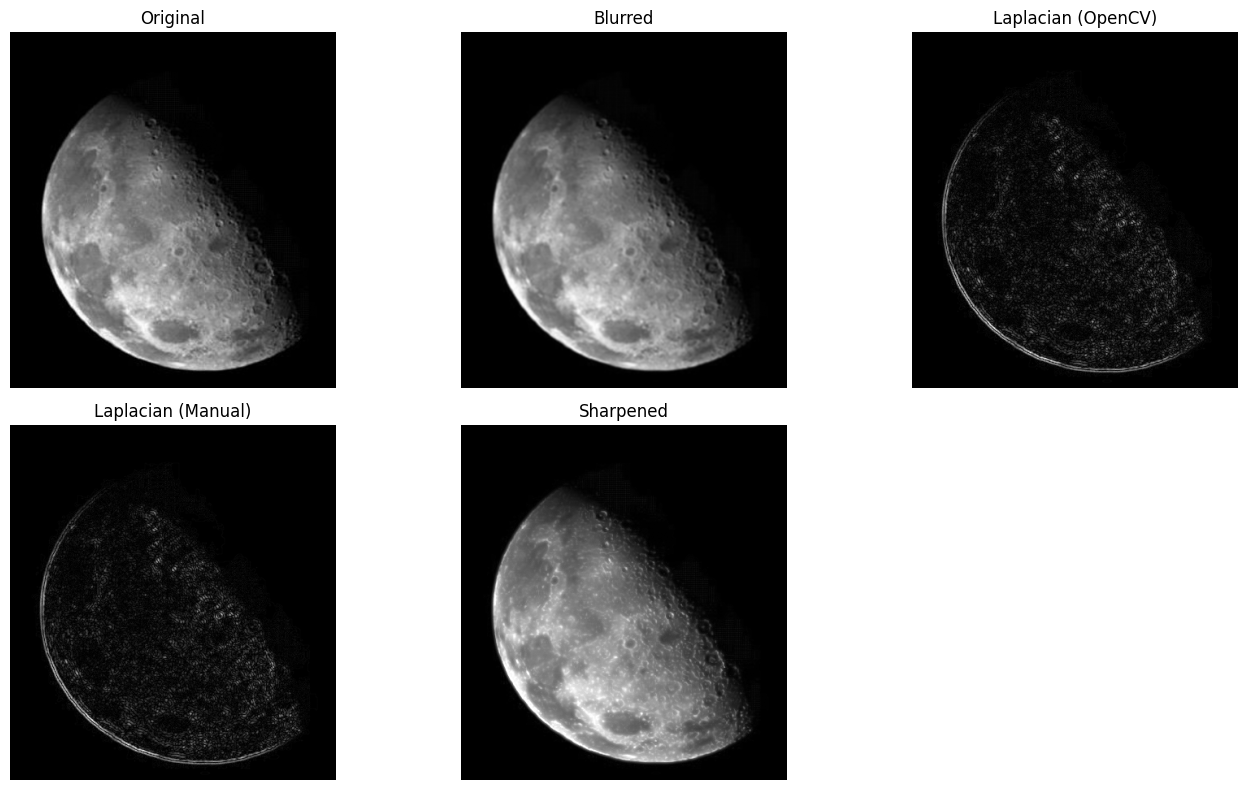

In [9]:
plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title("Blurred")
plt.imshow(blurred, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title("Laplacian (OpenCV)")
plt.imshow(laplacian_8bit, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title("Laplacian (Manual)")
plt.imshow(manual_laplacian_8bit, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("Sharpened")
plt.imshow(sharpened, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()